# 03 Clustering Analysis

This notebook conducts clustering analysis on the student dropout dataset, covering algorithm introduction, data loading, feature selection, clustering modeling, visualization, and multi-metric evaluation for K-means, Hierarchical Clustering, and Gaussian Mixture Model (GMM).

## 1. K-means algorithm

K-means is a commonly used distance-based clustering algorithm suitable for numerical features. Its goal is to divide data into K clusters such that the similarity of samples within the same cluster is maximized and the similarity between different clusters is minimized. It is applicable to large-sample datasets with standardized features.

In [1]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

### 1.1. Read preprocessed data
Use the standardized and one-hot encoded data generated by 01_preprocessing.ipynb.

In [2]:
df = pd.read_csv('../data/data_preprocessed.csv')
df.shape, df.columns[:5]

((4424, 240),
 Index(['Application order', 'Daytime/evening attendance',
        'Previous qualification (grade)', 'Admission grade', 'Displaced'],
       dtype='object'))

### 1.2. Feature selection

Remove the target variable and encoded columns, and perform clustering using only the features.

In [3]:
X = df.select_dtypes(include=[np.number])
if 'Target_encoded' in X.columns:
    X = X.drop(columns=['Target_encoded'])
X.shape

(4424, 27)

### 1.3. K-means Clustering Modeling and Clustering Visualization Under Different K Values (PCA Dimensionality Reduction)

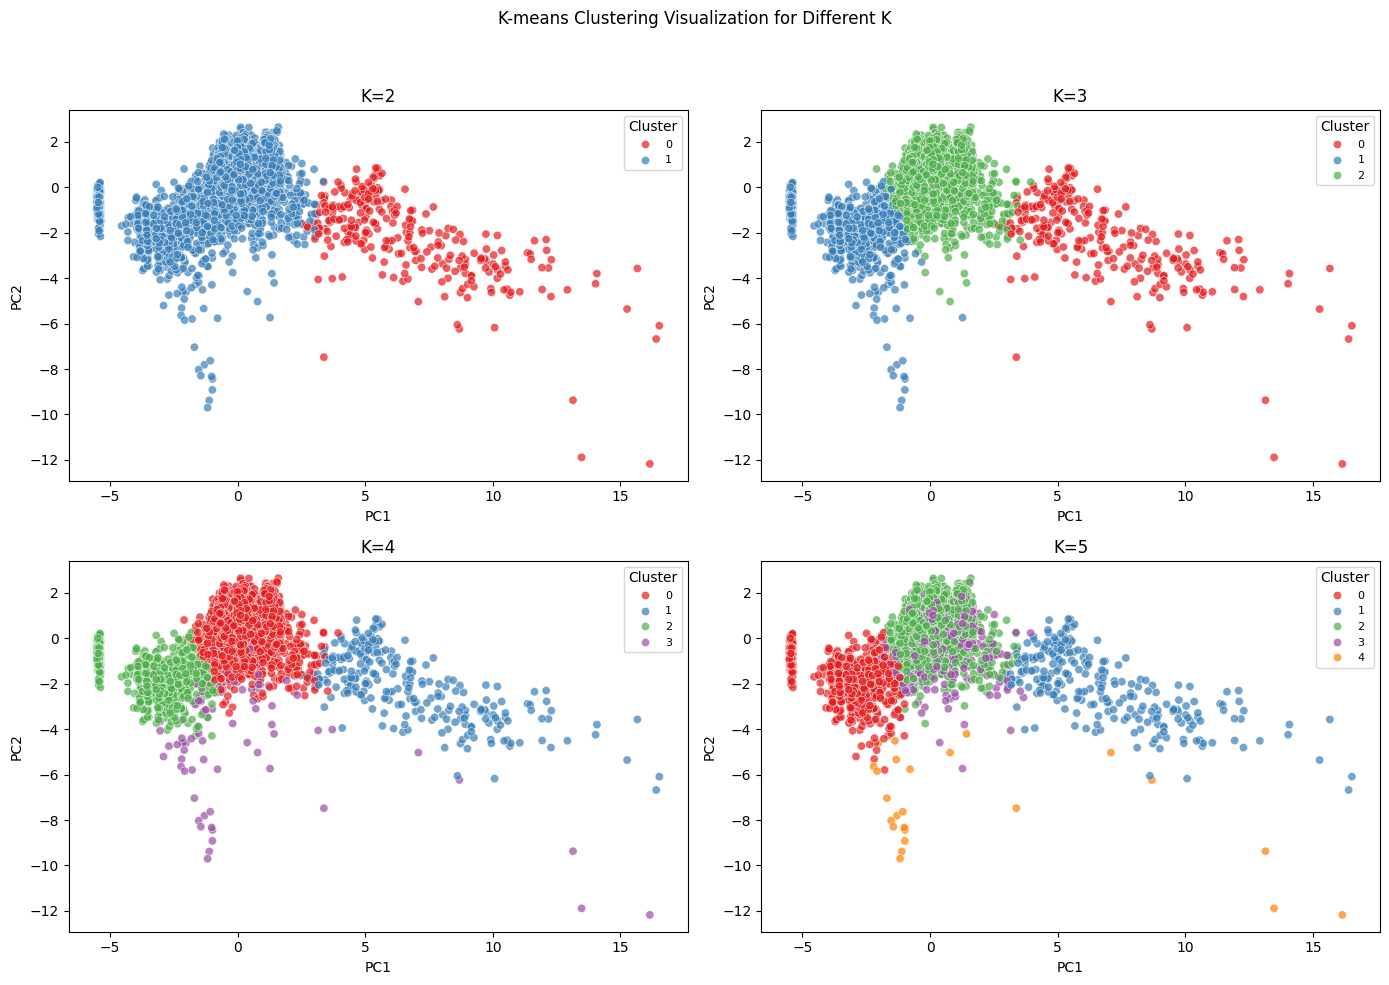

In [4]:
k_list = [2, 3, 4, 5]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X)
for idx, k in enumerate(k_list):
    # Fit K-means for each K
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X)
    row, col = divmod(idx, 2)
    # Scatter plot with cluster labels
    sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=labels, palette='Set1', alpha=0.7, ax=axes[row, col], legend='full')
    axes[row, col].set_title(f'K={k}')
    axes[row, col].set_xlabel('PC1')
    axes[row, col].set_ylabel('PC2')
    axes[row, col].legend(title='Cluster', fontsize=8)
plt.suptitle('K-means Clustering Visualization for Different K')
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

### 1.5. Clustering effect evaluation
The following compares various clustering evaluation metrics under different K values:
- Elbow Method: (As K increases, the SSE will keep decreasing, but when K is excessively large, the decline rate of SSE will become very small.) The "elbow" refers to the point where the SSE curve bends noticeably, and the K corresponding to the inflection point is regarded as the optimal number of clusters.
- Silhouette Coefficient: Measures intra-cluster compactness and inter-cluster separation, with a range of [-1, 1]; the closer to 1, the better.
- Calinski-Harabasz (CH): Ratio of inter-cluster variance to intra-cluster variance; the higher the value, the better.
- Davies-Bouldin (DB): Ratio of intra-cluster similarity to inter-cluster similarity; the lower the value, the better.
- ARI / Normalized Mutual Information (NMI): Compares clustering results with true labels; the closer to 1, the better.

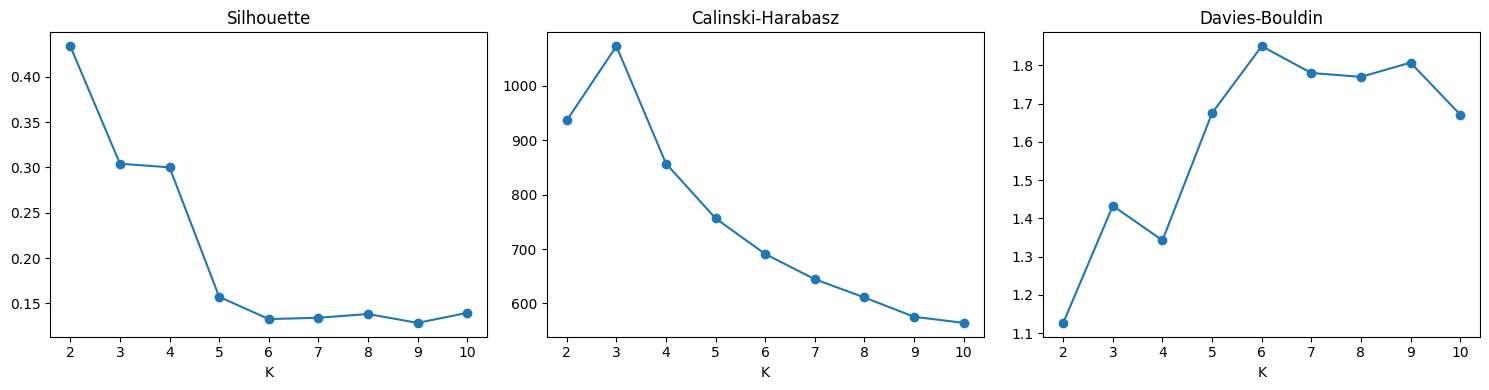

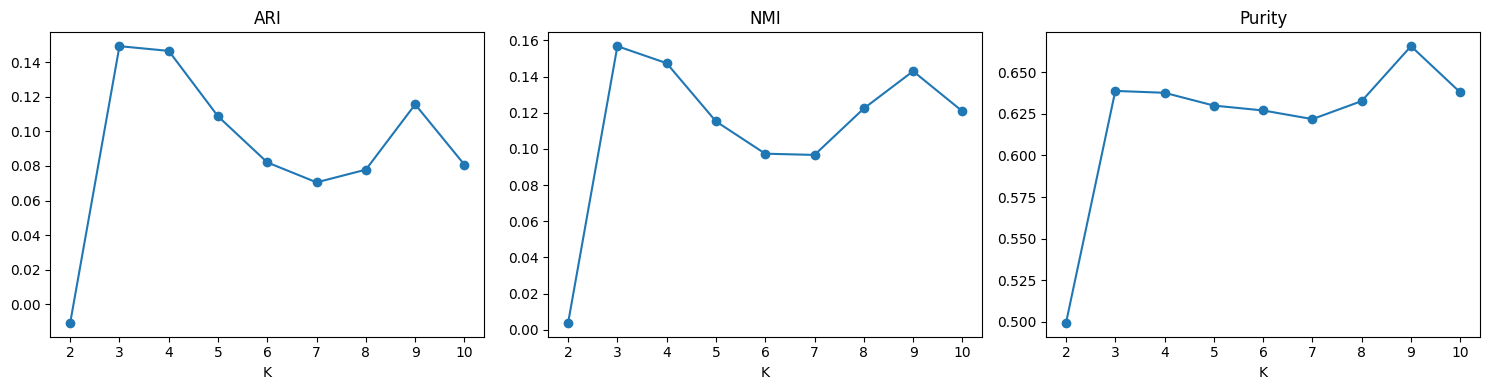

In [ ]:
from sklearn.metrics import calinski_harabasz_score, davies_bouldin_score, adjusted_rand_score, normalized_mutual_info_score

def purity_score(y_true, y_pred):
    from scipy.stats import mode
    labels = np.unique(y_pred)
    total = 0
    for label in labels:
        mask = (y_pred == label)
        if np.sum(mask) == 0: continue
        if len(np.unique(y_true[mask])) == 0: continue
        total += mode(y_true[mask], keepdims=True)[1][0]
    return total / len(y_true)

K_range = range(2, 11)
inertia = []
silhouette = []
ch_score = []
db_score = []
ari_score = []
nmi_score = []
purity = []
true_labels = df['Target_encoded'] if 'Target_encoded' in df.columns else None

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X)
    inertia.append(kmeans.inertia_)
    silhouette.append(silhouette_score(X, labels))
    ch_score.append(calinski_harabasz_score(X, labels))
    db_score.append(davies_bouldin_score(X, labels))
    if true_labels is not None:
        ari_score.append(adjusted_rand_score(true_labels, labels))
        nmi_score.append(normalized_mutual_info_score(true_labels, labels))
        purity.append(purity_score(true_labels, labels))
    else:
        ari_score.append(None)
        nmi_score.append(None)
        purity.append(None)

# Internal metrics
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].plot(K_range, silhouette, marker='o'); axes[0].set_title('Silhouette'); axes[0].set_xlabel('K')
axes[1].plot(K_range, ch_score, marker='o'); axes[1].set_title('Calinski-Harabasz'); axes[1].set_xlabel('K')
axes[2].plot(K_range, db_score, marker='o'); axes[2].set_title('Davies-Bouldin'); axes[2].set_xlabel('K')
plt.tight_layout()
plt.show()

# External metrics
if true_labels is not None:
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    axes[0].plot(K_range, ari_score, marker='o'); axes[0].set_title('ARI'); axes[0].set_xlabel('K')
    axes[1].plot(K_range, nmi_score, marker='o'); axes[1].set_title('NMI'); axes[1].set_xlabel('K')
    axes[2].plot(K_range, purity, marker='o'); axes[2].set_title('Purity'); axes[2].set_xlabel('K')
    plt.tight_layout()
    plt.show()

Based on multiple indicators and visualization, K-means (K=3) performs better.


## 2. Hierarchical Clustering
Hierarchical Clustering constructs a clustering tree from data objects. Common hierarchical clustering methods include agglomerative (bottom-up merging) and divisive (top-down splitting), with agglomerative clustering being more widely used. Hierarchical clustering is suitable for data analysis scenarios with a small sample size where a hierarchical clustering structure is desired.

### 2.1 Hierarchical clustering dendrogram
Plot a dendrogram for hierarchical clustering to observe the hierarchical structure and clustering process of the samples.

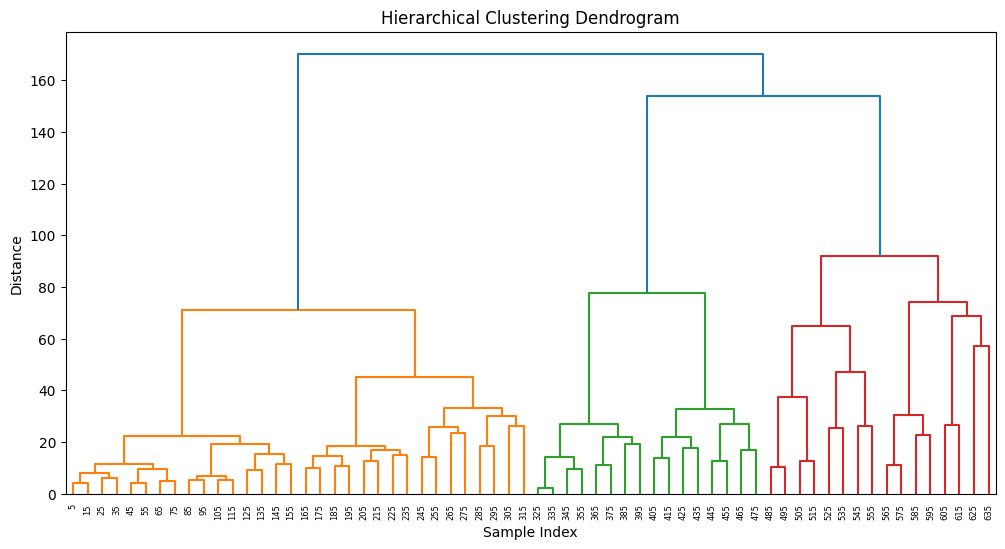

In [6]:
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage

# Select the distance metric and linkage method for hierarchical clustering; try 'ward','average', 'complete', 'single'
# Among them, 'ward' is applicable to Euclidean distance, 'average' represents average distance, 
# 'complete' represents maximum distance, and 'single' represents minimum distance.
linkage_method = 'ward'

# Calculate the linkage matrix for hierarchical clustering
Z = linkage(X, method=linkage_method)

# Draw a dendrogram and label the sample indices
plt.figure(figsize=(12, 6))
dendro = dendrogram(Z, truncate_mode='level', p=5)
plt.title('Hierarchical Clustering Dendrogram')
plt.xlabel('Sample Index')
plt.ylabel('Distance')
# Add sample index labels
if hasattr(df, 'index'):
    tick_locs = plt.xticks()[0]
    tick_labels = [str(int(i)) for i in tick_locs]
    plt.xticks(tick_locs, tick_labels, rotation=90)
plt.show()

### 2.2 Hierarchical Clustering Visualization (PCA Dimensionality Reduction)
After reducing the data to two dimensions, display the clustering distribution under different numbers of clusters.

### 2.3 Clustering Evaluation of Hierarchical Clustering with Different Numbers of Clusters
Conduct multi-index evaluation on hierarchical clustering results under different cluster numbers（Silhouette、Calinski-Harabasz、Davies-Bouldin、ARI、NMI）。

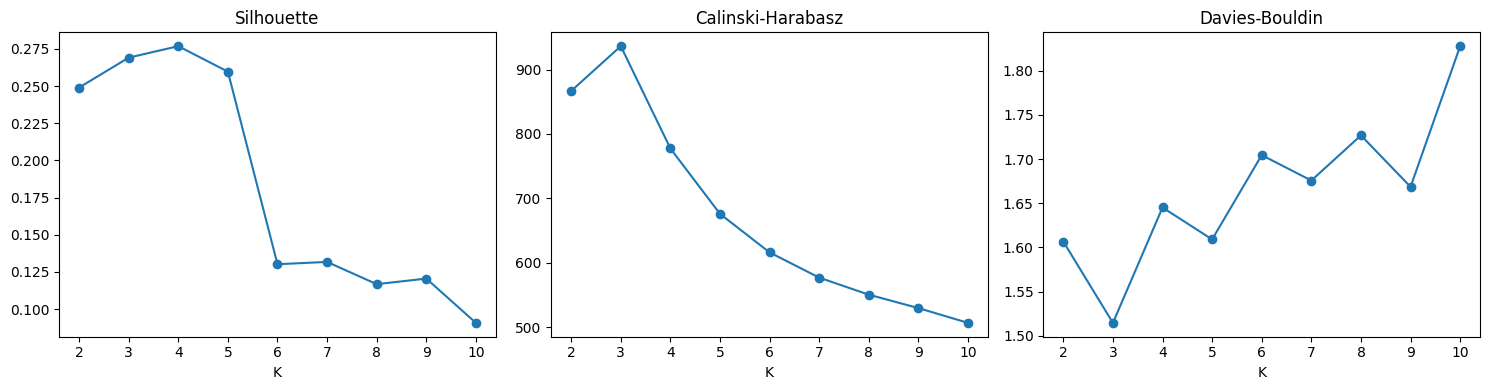

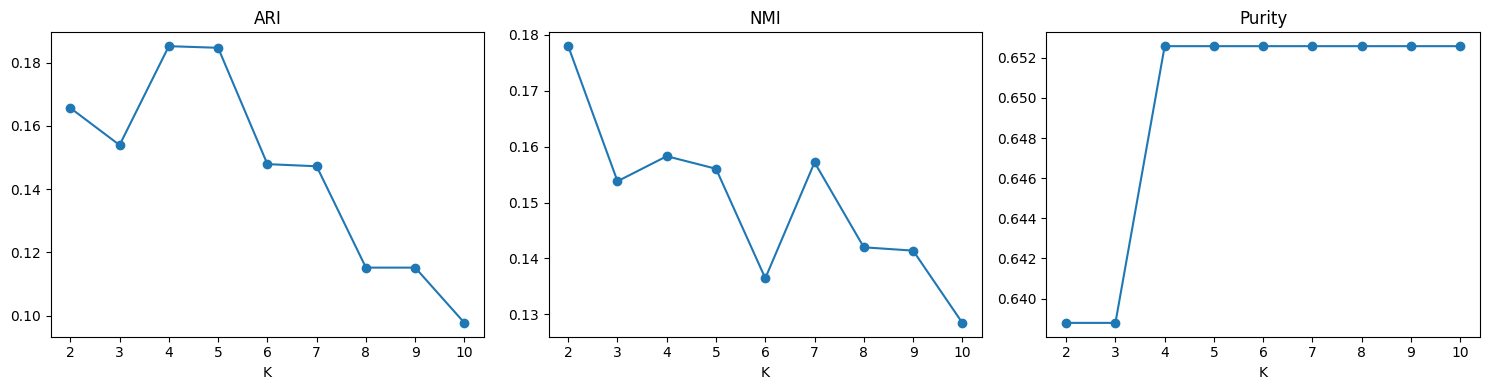

In [44]:
hc_silhouette = []
hc_ch_score = []
hc_db_score = []
hc_ari_score = []
hc_nmi_score = []
hc_purity = []

for k in K_range:
    hc = AgglomerativeClustering(n_clusters=k, linkage=linkage_method)
    hc_labels = hc.fit_predict(X)
    hc_silhouette.append(silhouette_score(X, hc_labels))
    hc_ch_score.append(calinski_harabasz_score(X, hc_labels))
    hc_db_score.append(davies_bouldin_score(X, hc_labels))
    if true_labels is not None:
        hc_ari_score.append(adjusted_rand_score(true_labels, hc_labels))
        hc_nmi_score.append(normalized_mutual_info_score(true_labels, hc_labels))
        hc_purity.append(purity_score(true_labels, hc_labels))
    else:
        hc_ari_score.append(None)
        hc_nmi_score.append(None)
        hc_purity.append(None)

# Internal metrics
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].plot(K_range, hc_silhouette, marker='o'); axes[0].set_title('Silhouette'); axes[0].set_xlabel('K')
axes[1].plot(K_range, hc_ch_score, marker='o'); axes[1].set_title('Calinski-Harabasz'); axes[1].set_xlabel('K')
axes[2].plot(K_range, hc_db_score, marker='o'); axes[2].set_title('Davies-Bouldin'); axes[2].set_xlabel('K')
plt.tight_layout()
plt.show()

# External metrics
if true_labels is not None:
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    axes[0].plot(K_range, hc_ari_score, marker='o'); axes[0].set_title('ARI'); axes[0].set_xlabel('K')
    axes[1].plot(K_range, hc_nmi_score, marker='o'); axes[1].set_title('NMI'); axes[1].set_xlabel('K')
    axes[2].plot(K_range, hc_purity, marker='o'); axes[2].set_title('Purity'); axes[2].set_xlabel('K')
    plt.tight_layout()
    plt.show()

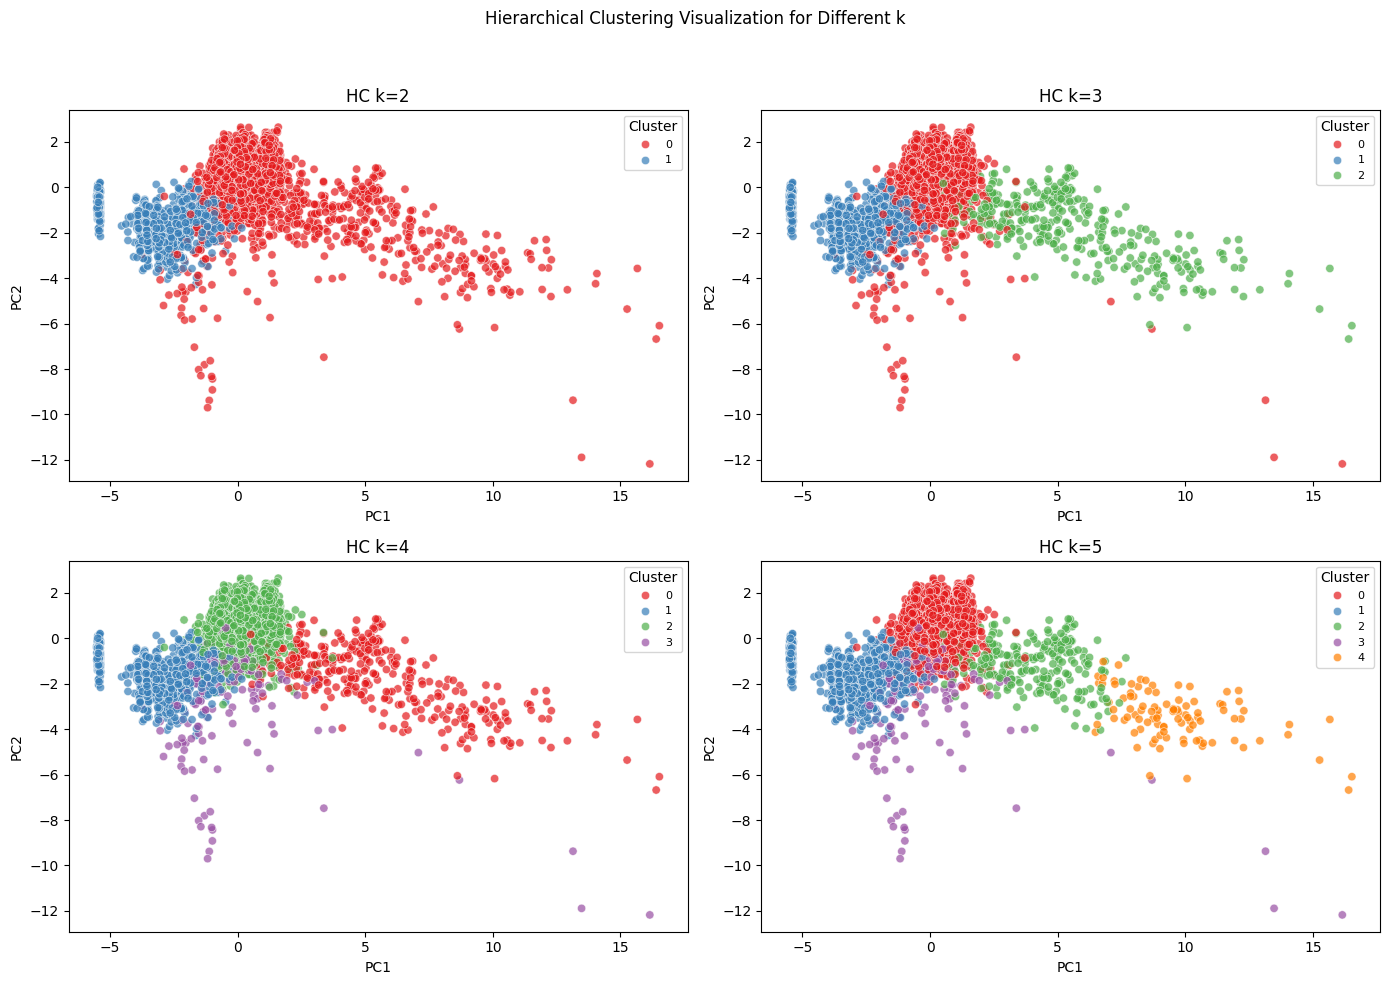

In [45]:
hc_k_list = [2, 3, 4, 5]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for idx, k in enumerate(hc_k_list):
    hc = AgglomerativeClustering(n_clusters=k, linkage=linkage_method)
    hc_labels = hc.fit_predict(X)
    row, col = divmod(idx, 2)
    sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=hc_labels, palette='Set1', alpha=0.7, ax=axes[row, col], legend='full')
    axes[row, col].set_title(f'HC k={k}')
    axes[row, col].set_xlabel('PC1')
    axes[row, col].set_ylabel('PC2')
    axes[row, col].legend(title='Cluster', fontsize=8)
plt.suptitle('Hierarchical Clustering Visualization for Different k')
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

Based on the comprehensive evaluation indicators and visualization results, each indicator performs better when k=3.

## 3. Gaussian Mixture Model (GMM) 

Gaussian Mixture Model (GMM) is a clustering method based on probabilistic models, which assumes that data is formed by the mixture of multiple Gaussian distributions. Parameters are estimated through the Expectation-Maximization (EM) algorithm, and the probability of each sample belonging to each cluster is output.

### 3.1 Usage and Visualization of the GMM Algorithm

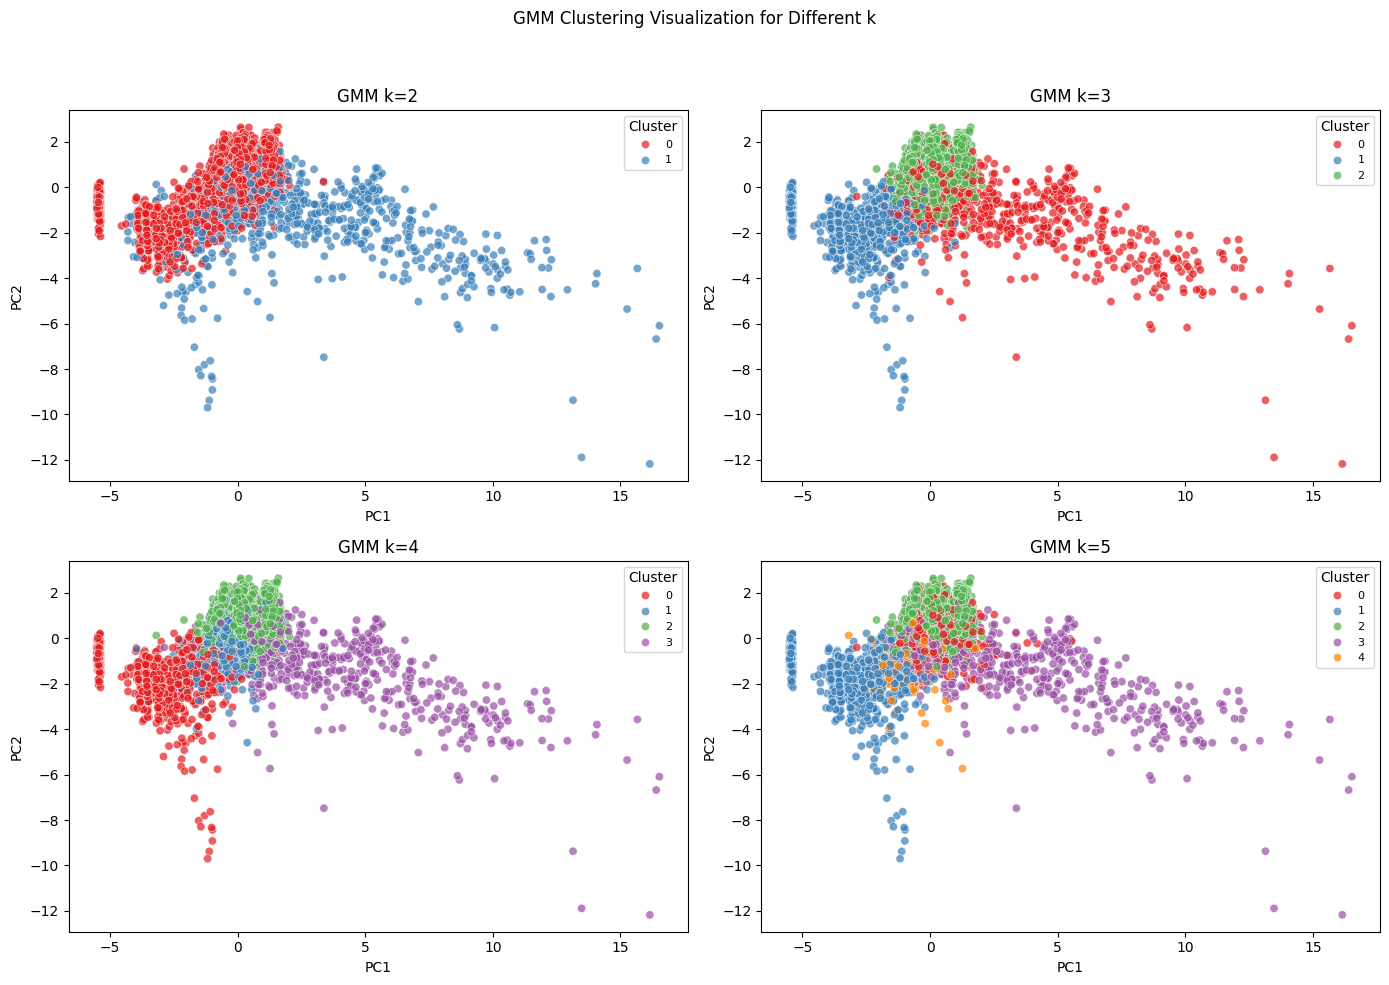

In [47]:
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score, adjusted_rand_score, normalized_mutual_info_score
import matplotlib.pyplot as plt
import seaborn as sns

# Select different cluster numbers K
k_list = [2, 3, 4, 5]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for idx, k in enumerate(k_list):
    gmm = GaussianMixture(n_components=k, random_state=42, covariance_type='full', n_init=5)
    gmm_labels = gmm.fit_predict(X)
    row, col = divmod(idx, 2)
    sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=gmm_labels, palette='Set1', alpha=0.7, ax=axes[row, col], legend='full')
    axes[row, col].set_title(f'GMM k={k}')
    axes[row, col].set_xlabel('PC1')
    axes[row, col].set_ylabel('PC2')
    axes[row, col].legend(title='Cluster', fontsize=8)
plt.suptitle('GMM Clustering Visualization for Different k')
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

### 3.2 Multi-index Evaluation of GMM Clustering Performance

For the GMM clustering results under different K values, calculate metrics such as silhouette coefficient, Calinski-Harabasz, Davies-Bouldin, ARI, and NMI.

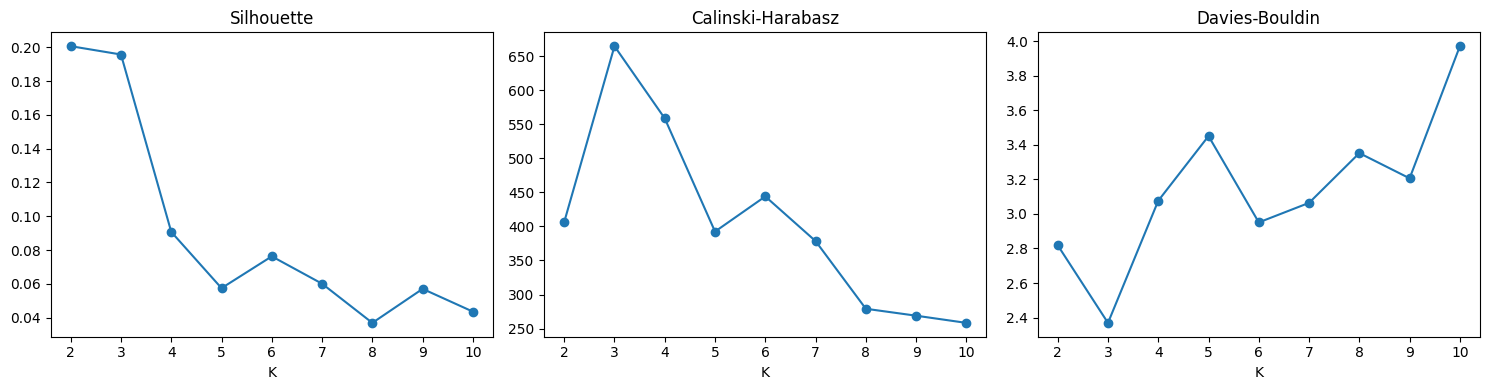

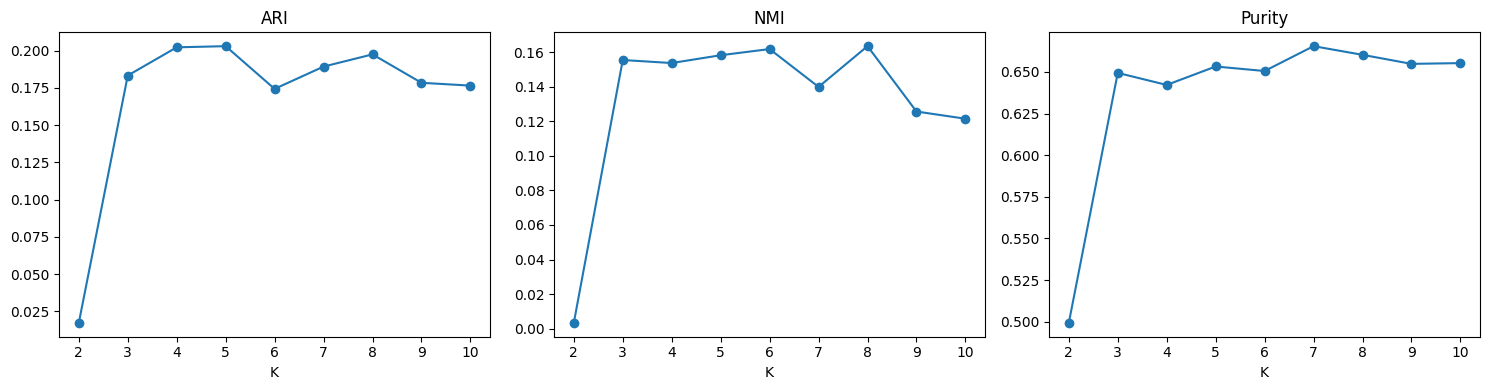

In [48]:
gmm_silhouette = []
gmm_ch_score = []
gmm_db_score = []
gmm_ari_score = []
gmm_nmi_score = []
gmm_purity = []

for k in K_range:
    gmm = GaussianMixture(n_components=k, random_state=42, covariance_type='full', n_init=5)
    gmm_labels = gmm.fit_predict(X)
    gmm_silhouette.append(silhouette_score(X, gmm_labels))
    gmm_ch_score.append(calinski_harabasz_score(X, gmm_labels))
    gmm_db_score.append(davies_bouldin_score(X, gmm_labels))
    if true_labels is not None:
        gmm_ari_score.append(adjusted_rand_score(true_labels, gmm_labels))
        gmm_nmi_score.append(normalized_mutual_info_score(true_labels, gmm_labels))
        gmm_purity.append(purity_score(true_labels, gmm_labels))
    else:
        gmm_ari_score.append(None)
        gmm_nmi_score.append(None)
        gmm_purity.append(None)

# Internal metrics
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].plot(list(K_range), gmm_silhouette, marker='o'); axes[0].set_title('Silhouette'); axes[0].set_xlabel('K')
axes[1].plot(list(K_range), gmm_ch_score, marker='o'); axes[1].set_title('Calinski-Harabasz'); axes[1].set_xlabel('K')
axes[2].plot(list(K_range), gmm_db_score, marker='o'); axes[2].set_title('Davies-Bouldin'); axes[2].set_xlabel('K')
plt.tight_layout()
plt.show()

# External metrics
if true_labels is not None:
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    axes[0].plot(list(K_range), gmm_ari_score, marker='o'); axes[0].set_title('ARI'); axes[0].set_xlabel('K')
    axes[1].plot(list(K_range), gmm_nmi_score, marker='o'); axes[1].set_title('NMI'); axes[1].set_xlabel('K')
    axes[2].plot(list(K_range), gmm_purity, marker='o'); axes[2].set_title('Purity'); axes[2].set_xlabel('K')
    plt.tight_layout()
    plt.show()

Consider comprehensively, k=3 is a relatively optimal choice.

## 4. Comparison of Three Clustering Algorithms and Performance Analysis in This Project

This project applies three clustering algorithms, namely K-means, Hierarchical Clustering, and Gaussian Mixture Model (GMM), to the student dropout dataset. Each of them has its own characteristics:

- K-means is suitable for data with a large sample size, standardized features and spherical clusters. The algorithm is efficient and the results are intuitive, but it is not sensitive to outliers and non-spherical clusters.
- Hierarchical clustering can reveal the hierarchical structure of data and is suitable for small samples and scenarios requiring hierarchical analysis, but it has low efficiency on large datasets.
- GMM can fit elliptical, overlapping or differently varianced clusters, making it suitable for data with complex distributions, and can output the probability of each sample belonging to each cluster.

In [49]:
kmeans_idx = 3
hc_idx = 3
gmm_idx = 3

# K-means
kmeans_sil = silhouette[kmeans_idx]
kmeans_ch = ch_score[kmeans_idx]
kmeans_db = db_score[kmeans_idx]
kmeans_ari = ari_score[kmeans_idx] if true_labels is not None else None
kmeans_nmi = nmi_score[kmeans_idx] if true_labels is not None else None
kmeans_purity_val = purity[kmeans_idx] if true_labels is not None else None

# Hierarchical Clustering
hc_sil = hc_silhouette[hc_idx]
hc_ch = hc_ch_score[hc_idx]
hc_db = hc_db_score[hc_idx]
hc_ari = hc_ari_score[hc_idx] if true_labels is not None else None
hc_nmi = hc_nmi_score[hc_idx] if true_labels is not None else None
hc_purity_val = hc_purity[hc_idx] if true_labels is not None else None

# GMM
gmm_sil = gmm_silhouette[gmm_idx]
gmm_ch = gmm_ch_score[gmm_idx]
gmm_db = gmm_db_score[gmm_idx]
gmm_ari = gmm_ari_score[gmm_idx] if true_labels is not None else None
gmm_nmi = gmm_nmi_score[gmm_idx] if true_labels is not None else None
gmm_purity_val = gmm_purity[gmm_idx] if true_labels is not None else None


result_df = pd.DataFrame({
    'Algorithms': ['K-means', 'Hierarchical', 'GMM'],
    'Silhouette': [kmeans_sil, hc_sil, gmm_sil],
    'CH': [kmeans_ch, hc_ch, gmm_ch],
    'DB': [kmeans_db, hc_db, gmm_db],
    'ARI': [kmeans_ari, hc_ari, gmm_ari],
    'NMI': [kmeans_nmi, hc_nmi, gmm_nmi],
    'Purity': [kmeans_purity_val, hc_purity_val, gmm_purity_val],
})
display(result_df.style.format({'Silhouette': '{:.3f}', 'CH': '{:.2f}', 'DB': '{:.2f}', 'ARI': '{:.3f}', 'NMI': '{:.3f}', 'Purity': '{:.3f}'}).set_caption('Comparison of Clustering Algorithm Evaluation Metrics'))

,Algorithms,Silhouette,CH,DB,ARI,NMI,Purity
0,K-means,0.157,756.45,1.68,0.109,0.115,0.630
1,Hierarchical,0.260,675.80,1.61,0.185,0.156,0.653
2,GMM,0.058,392.39,3.45,0.203,0.158,0.653


Combined with the clustering visualization and multi-index evaluation results of this project, all three algorithms can effectively restore the main structure of the data when K=3, and indicators such as the silhouette coefficient perform relatively well. 

Among them, **K-means** exhibits the most outstanding performance on this dataset, with clear clustering boundaries and optimal indicators, making it suitable for mainstream structural analysis in this task.